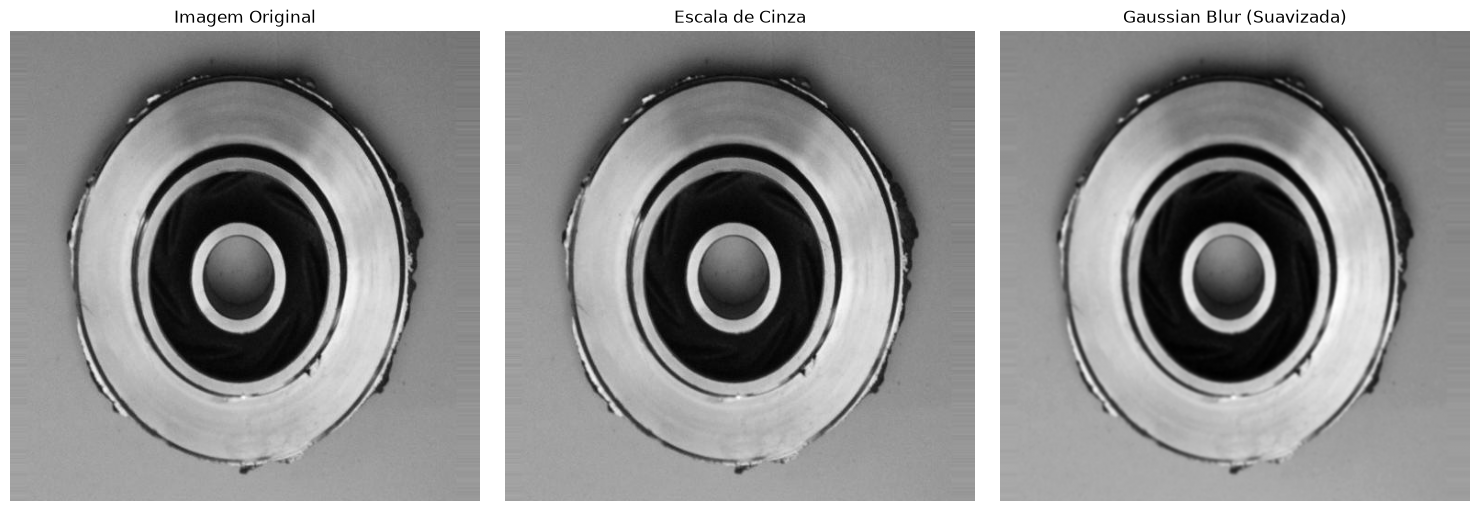

In [9]:
import cv2
import matplotlib.pyplot as plt
import os

# 1. Definir o caminho de uma imagem de amostra (Ajuste o nome do arquivo conforme o seu dataset)
# Escolha uma imagem que tenha defeito para visualizarmos melhor
# Ajustando o caminho para incluir as pastas 'casting_data' geradas na extração
#image_path = '../data/casting_512x512/casting_data/train/def_front/cast_def_0_0.jpeg' # <- VERIFIQUE O CAMINHO EXATO DA IMAGEM
image_path = '../data/casting_512x512/def_front/cast_def_0_0.jpeg'

# 2. Carregar a imagem original
img_bgr = cv2.imread(image_path)
# O OpenCV lê em BGR, vamos converter para RGB para o Matplotlib exibir corretamente a cor original
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# 3. Converter para Escala de Cinza (Grayscale)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# 4. Aplicar Suavização (Gaussian Blur) para reduzir ruído industrial
# O kernel (5,5) define a intensidade do desfoque
img_blur = cv2.GaussianBlur(img_gray, (5, 5), 0)

# 5. Plotar os resultados lado a lado
plt.figure(figsize=(15, 5))

# Original
plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title('Imagem Original')
plt.axis('off')

# Escala de Cinza
plt.subplot(1, 3, 2)
plt.imshow(img_gray, cmap='gray')
plt.title('Escala de Cinza')
plt.axis('off')

# Blur
plt.subplot(1, 3, 3)
plt.imshow(img_blur, cmap='gray')
plt.title('Gaussian Blur (Suavizada)')
plt.axis('off')

plt.tight_layout()
plt.show()

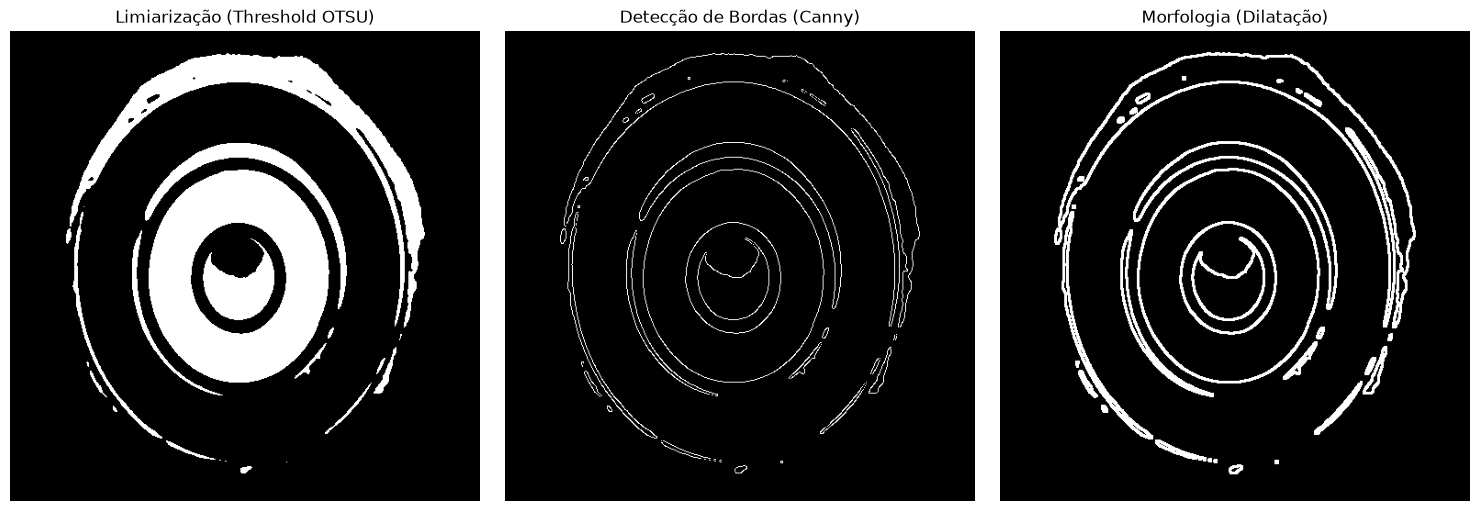

In [10]:
import numpy as np

# 1. Limiarização (Thresholding)
# Converte a imagem em pixels estritamente pretos (0) ou brancos (255) para isolar formas
# Usamos o método de Otsu para encontrar o valor de corte ideal automaticamente
_, img_thresh = cv2.threshold(img_blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# 2. Detecção de Bordas (Canny)
# Mapeia os contornos das estruturas encontradas na imagem limiarizada
img_canny = cv2.Canny(img_thresh, 100, 200)

# 3. Operações Morfológicas (Dilatação)
# Cria um "kernel" (matriz 3x3) para expandir (dilatar) as bordas detectadas, 
# tornando a trinca ou defeito muito mais evidente e fechando pequenos buracos
kernel = np.ones((3, 3), np.uint8)
img_dilated = cv2.dilate(img_canny, kernel, iterations=1)

# 4. Plotar os resultados lado a lado
plt.figure(figsize=(15, 5))

# Limiarização
plt.subplot(1, 3, 1)
plt.imshow(img_thresh, cmap='gray')
plt.title('Limiarização (Threshold OTSU)')
plt.axis('off')

# Bordas (Canny)
plt.subplot(1, 3, 2)
plt.imshow(img_canny, cmap='gray')
plt.title('Detecção de Bordas (Canny)')
plt.axis('off')

# Morfologia
plt.subplot(1, 3, 3)
plt.imshow(img_dilated, cmap='gray')
plt.title('Morfologia (Dilatação)')
plt.axis('off')

plt.tight_layout()
plt.show()